In [2]:
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Model
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

print("✅ All imports successful!")
print(f"TensorFlow version: {tf.__version__}")
print(f"GPU available: {tf.config.list_physical_devices('GPU')}")

✅ All imports successful!
TensorFlow version: 2.21.0
GPU available: []


In [3]:
PROCESSED_PATH = r"D:\Development\8th Sem Project\TomatoClassification\dataset\processed_mixed"
MODEL_PATH      = r"D:\Development\8th Sem Project\TomatoClassification\models"

IMAGE_SIZE  = (224, 224)
BATCH_SIZE  = 32
NUM_CLASSES = 10
EPOCHS      = 20
STRATEGY    = "C_Mixed"

os.makedirs(MODEL_PATH, exist_ok=True)

print(f"✅ Paths configured!")
print(f"📁 Dataset : {PROCESSED_PATH}")
print(f"💾 Models  : {MODEL_PATH}")
print(f"🖼️  Image size : {IMAGE_SIZE}")
print(f"📦 Batch size : {BATCH_SIZE}")
print(f"🔁 Epochs     : {EPOCHS}")

✅ Paths configured!
📁 Dataset : D:\Development\8th Sem Project\TomatoClassification\dataset\processed_mixed
💾 Models  : D:\Development\8th Sem Project\TomatoClassification\models
🖼️  Image size : (224, 224)
📦 Batch size : 32
🔁 Epochs     : 20


In [4]:
# Training data — with augmentation
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=15,
    horizontal_flip=True,
    zoom_range=0.1,
    width_shift_range=0.1,
    height_shift_range=0.1
)

# Validation & Test — NO augmentation, only rescale
val_test_datagen = ImageDataGenerator(rescale=1./255)

# Load training images
train_generator = train_datagen.flow_from_directory(
    os.path.join(PROCESSED_PATH, 'train'),
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=True
)

# Load validation images
val_generator = val_test_datagen.flow_from_directory(
    os.path.join(PROCESSED_PATH, 'val'),
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

# Load test images
test_generator = val_test_datagen.flow_from_directory(
    os.path.join(PROCESSED_PATH, 'test'),
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

print(f"\n✅ Data loaded!")
print(f"🏋️  Training   : {train_generator.samples} images")
print(f"✔️  Validation : {val_generator.samples} images")
print(f"🧪 Test       : {test_generator.samples} images")
print(f"\n📋 Classes found: {list(train_generator.class_indices.keys())}")

Found 6822 images belonging to 10 classes.
Found 1462 images belonging to 10 classes.
Found 1462 images belonging to 10 classes.

✅ Data loaded!
🏋️  Training   : 6822 images
✔️  Validation : 1462 images
🧪 Test       : 1462 images

📋 Classes found: ['Tomato___Bacterial_spot', 'Tomato___Early_blight', 'Tomato___Late_blight', 'Tomato___Leaf_Mold', 'Tomato___Septoria_leaf_spot', 'Tomato___Spider_mites Two-spotted_spider_mite', 'Tomato___Target_Spot', 'Tomato___Tomato_Yellow_Leaf_Curl_Virus', 'Tomato___Tomato_mosaic_virus', 'Tomato___healthy']


In [5]:
# Load MobileNetV2 pretrained on ImageNet, without its top layer
base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)

# Freeze base model — don't retrain pretrained weights
base_model.trainable = False

# Add our custom classification layers on top
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.3)(x)
output = Dense(NUM_CLASSES, activation='softmax')(x)

# Combine into final model
model = Model(inputs=base_model.input, outputs=output)

# Compile
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("✅ Fresh model built for Strategy c!")
print(f"📊 Total layers      : {len(model.layers)}")
print(f"🔒 Trainable params  : {model.count_params():,}")
#model.summary()

✅ Fresh model built for Strategy c!
📊 Total layers      : 158
🔒 Trainable params  : 2,423,242


In [6]:
#Cell 5 — Train the Model
callbacks = [
    EarlyStopping(
        monitor='val_loss',
        patience=5,
        restore_best_weights=True,
        verbose=1
    ),
    ModelCheckpoint(
        filepath=os.path.join(MODEL_PATH, f'best_model_{STRATEGY}.h5'),
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=3,
        min_lr=1e-6,
        verbose=1
    )
]

print(f"🚀 Starting Training — Strategy {STRATEGY}...\n")

history = model.fit(
    train_generator,
    epochs=EPOCHS,
    validation_data=val_generator,
    callbacks=callbacks
)

print(f"\n✅ Training Complete — Strategy {STRATEGY}!")
print(f"📊 Best Val Accuracy : {max(history.history['val_accuracy']):.2%}")

🚀 Starting Training — Strategy C_Mixed...

Epoch 1/20
214/214 ━━━━━━━━━━━━━━━━━━━━ 0s 949ms/step - accuracy: 0.4453 - loss: 1.6128
Epoch 1: val_accuracy improved from None to 0.73666, saving model to D:\Development\8th Sem Project\TomatoClassification\models\best_model_C_Mixed.h5



Epoch 1: finished saving model to D:\Development\8th Sem Project\TomatoClassification\models\best_model_C_Mixed.h5
214/214 ━━━━━━━━━━━━━━━━━━━━ 244s 1s/step - accuracy: 0.5833 - loss: 1.2216 - val_accuracy: 0.7367 - val_loss: 0.7592 - learning_rate: 0.0010
Epoch 2/20
214/214 ━━━━━━━━━━━━━━━━━━━━ 0s 702ms/step - accuracy: 0.7404 - loss: 0.7795
Epoch 2: val_accuracy improved from 0.73666 to 0.79275, saving model to D:\Development\8th Sem Project\TomatoClassification\models\best_model_C_Mixed.h5



Epoch 2: finished saving model to D:\Development\8th Sem Project\TomatoClassification\models\best_model_C_Mixed.h5
214/214 ━━━━━━━━━━━━━━━━━━━━ 178s 830ms/step - accuracy: 0.7426 - loss: 0.7689 - val_accuracy: 0.7927 - val_loss: 0.6053 - learning_rate: 0.0010
Epoch 3/20
214/214 ━━━━━━━━━━━━━━━━━━━━ 0s 710ms/step - accuracy: 0.7692 - loss: 0.6577
Epoch 3: val_accuracy improved from 0.79275 to 0.81190, saving model to D:\Development\8th Sem Project\TomatoClassification\models\best_model_C_Mixed.h5



Epoch 3: finished saving model to D:\Development\8th Sem Project\TomatoClassification\models\best_model_C_Mixed.h5
214/214 ━━━━━━━━━━━━━━━━━━━━ 179s 838ms/step - accuracy: 0.7744 - loss: 0.6588 - val_accuracy: 0.8119 - val_loss: 0.5513 - learning_rate: 0.0010
Epoch 4/20
214/214 ━━━━━━━━━━━━━━━━━━━━ 0s 713ms/step - accuracy: 0.8077 - loss: 0.5689
Epoch 4: val_accuracy improved from 0.81190 to 0.82148, saving model to D:\Development\8th Sem Project\TomatoClassification\models\best_model_C_Mixed.h5



Epoch 4: finished saving model to D:\Development\8th Sem Project\TomatoClassification\models\best_model_C_Mixed.h5
214/214 ━━━━━━━━━━━━━━━━━━━━ 180s 841ms/step - accuracy: 0.7977 - loss: 0.5839 - val_accuracy: 0.8215 - val_loss: 0.5285 - learning_rate: 0.0010
Epoch 5/20
214/214 ━━━━━━━━━━━━━━━━━━━━ 0s 711ms/step - accuracy: 0.8152 - loss: 0.5328
Epoch 5: val_accuracy improved from 0.82148 to 0.84542, saving model to D:\Development\8th Sem Project\TomatoClassification\models\best_model_C_Mixed.h5



Epoch 5: finished saving model to D:\Development\8th Sem Project\TomatoClassification\models\best_model_C_Mixed.h5
214/214 ━━━━━━━━━━━━━━━━━━━━ 179s 839ms/step - accuracy: 0.8153 - loss: 0.5340 - val_accuracy: 0.8454 - val_loss: 0.4612 - learning_rate: 0.0010
Epoch 6/20
214/214 ━━━━━━━━━━━━━━━━━━━━ 0s 705ms/step - accuracy: 0.8226 - loss: 0.4922
Epoch 6: val_accuracy did not improve from 0.84542
214/214 ━━━━━━━━━━━━━━━━━━━━ 178s 831ms/step - accuracy: 0.8225 - loss: 0.4998 - val_accuracy: 0.8317 - val_loss: 0.5011 - learning_rate: 0.0010
Epoch 7/20
214/214 ━━━━━━━━━━━━━━━━━━━━ 0s 720ms/step - accuracy: 0.8320 - loss: 0.4714
Epoch 7: val_accuracy did not improve from 0.84542
214/214 ━━━━━━━━━━━━━━━━━━━━ 181s 845ms/step - accuracy: 0.8303 - loss: 0.4792 - val_accuracy: 0.8324 - val_loss: 0.4937 - learning_rate: 0.0010
Epoch 8/20
214/214 ━━━━━━━━━━━━━━━━━━━━ 0s 720ms/step - accuracy: 0.8460 - loss: 0.4513
Epoch 8: val_accuracy improved from 0.84542 to 0.85157, saving model to D:\Developm


Epoch 8: finished saving model to D:\Development\8th Sem Project\TomatoClassification\models\best_model_C_Mixed.h5
214/214 ━━━━━━━━━━━━━━━━━━━━ 183s 853ms/step - accuracy: 0.8446 - loss: 0.4487 - val_accuracy: 0.8516 - val_loss: 0.4423 - learning_rate: 0.0010
Epoch 9/20
214/214 ━━━━━━━━━━━━━━━━━━━━ 0s 712ms/step - accuracy: 0.8537 - loss: 0.4281
Epoch 9: val_accuracy did not improve from 0.85157
214/214 ━━━━━━━━━━━━━━━━━━━━ 179s 838ms/step - accuracy: 0.8527 - loss: 0.4331 - val_accuracy: 0.8434 - val_loss: 0.4457 - learning_rate: 0.0010
Epoch 10/20
214/214 ━━━━━━━━━━━━━━━━━━━━ 0s 715ms/step - accuracy: 0.8512 - loss: 0.4156
Epoch 10: val_accuracy did not improve from 0.85157
214/214 ━━━━━━━━━━━━━━━━━━━━ 188s 878ms/step - accuracy: 0.8519 - loss: 0.4217 - val_accuracy: 0.8406 - val_loss: 0.4511 - learning_rate: 0.0010
Epoch 11/20
214/214 ━━━━━━━━━━━━━━━━━━━━ 0s 884ms/step - accuracy: 0.8589 - loss: 0.4090
Epoch 11: val_accuracy did not improve from 0.85157
214/214 ━━━━━━━━━━━━━━━━━━━━


Epoch 12: finished saving model to D:\Development\8th Sem Project\TomatoClassification\models\best_model_C_Mixed.h5
214/214 ━━━━━━━━━━━━━━━━━━━━ 210s 980ms/step - accuracy: 0.8635 - loss: 0.3894 - val_accuracy: 0.8564 - val_loss: 0.4139 - learning_rate: 0.0010
Epoch 13/20
214/214 ━━━━━━━━━━━━━━━━━━━━ 0s 807ms/step - accuracy: 0.8607 - loss: 0.3911
Epoch 13: val_accuracy improved from 0.85636 to 0.86525, saving model to D:\Development\8th Sem Project\TomatoClassification\models\best_model_C_Mixed.h5



Epoch 13: finished saving model to D:\Development\8th Sem Project\TomatoClassification\models\best_model_C_Mixed.h5
214/214 ━━━━━━━━━━━━━━━━━━━━ 204s 954ms/step - accuracy: 0.8701 - loss: 0.3763 - val_accuracy: 0.8653 - val_loss: 0.3997 - learning_rate: 0.0010
Epoch 14/20
214/214 ━━━━━━━━━━━━━━━━━━━━ 0s 833ms/step - accuracy: 0.8774 - loss: 0.3599
Epoch 14: val_accuracy did not improve from 0.86525
214/214 ━━━━━━━━━━━━━━━━━━━━ 210s 980ms/step - accuracy: 0.8735 - loss: 0.3788 - val_accuracy: 0.8290 - val_loss: 0.4994 - learning_rate: 0.0010
Epoch 15/20
214/214 ━━━━━━━━━━━━━━━━━━━━ 0s 829ms/step - accuracy: 0.8822 - loss: 0.3453
Epoch 15: val_accuracy did not improve from 0.86525
214/214 ━━━━━━━━━━━━━━━━━━━━ 209s 977ms/step - accuracy: 0.8816 - loss: 0.3483 - val_accuracy: 0.8618 - val_loss: 0.3978 - learning_rate: 0.0010
Epoch 16/20
214/214 ━━━━━━━━━━━━━━━━━━━━ 0s 766ms/step - accuracy: 0.8756 - loss: 0.3583
Epoch 16: val_accuracy did not improve from 0.86525
214/214 ━━━━━━━━━━━━━━━━━


Epoch 17: finished saving model to D:\Development\8th Sem Project\TomatoClassification\models\best_model_C_Mixed.h5
214/214 ━━━━━━━━━━━━━━━━━━━━ 206s 965ms/step - accuracy: 0.8799 - loss: 0.3270 - val_accuracy: 0.8714 - val_loss: 0.3827 - learning_rate: 0.0010
Epoch 18/20
214/214 ━━━━━━━━━━━━━━━━━━━━ 0s 774ms/step - accuracy: 0.8777 - loss: 0.3375
Epoch 18: val_accuracy did not improve from 0.87141
214/214 ━━━━━━━━━━━━━━━━━━━━ 198s 926ms/step - accuracy: 0.8817 - loss: 0.3302 - val_accuracy: 0.8687 - val_loss: 0.3920 - learning_rate: 0.0010
Epoch 19/20
214/214 ━━━━━━━━━━━━━━━━━━━━ 0s 859ms/step - accuracy: 0.8879 - loss: 0.3233
Epoch 19: val_accuracy did not improve from 0.87141
214/214 ━━━━━━━━━━━━━━━━━━━━ 215s 1s/step - accuracy: 0.8880 - loss: 0.3207 - val_accuracy: 0.8673 - val_loss: 0.4092 - learning_rate: 0.0010
Epoch 20/20
214/214 ━━━━━━━━━━━━━━━━━━━━ 0s 818ms/step - accuracy: 0.8946 - loss: 0.3045
Epoch 20: val_accuracy did not improve from 0.87141

Epoch 20: ReduceLROnPlateau

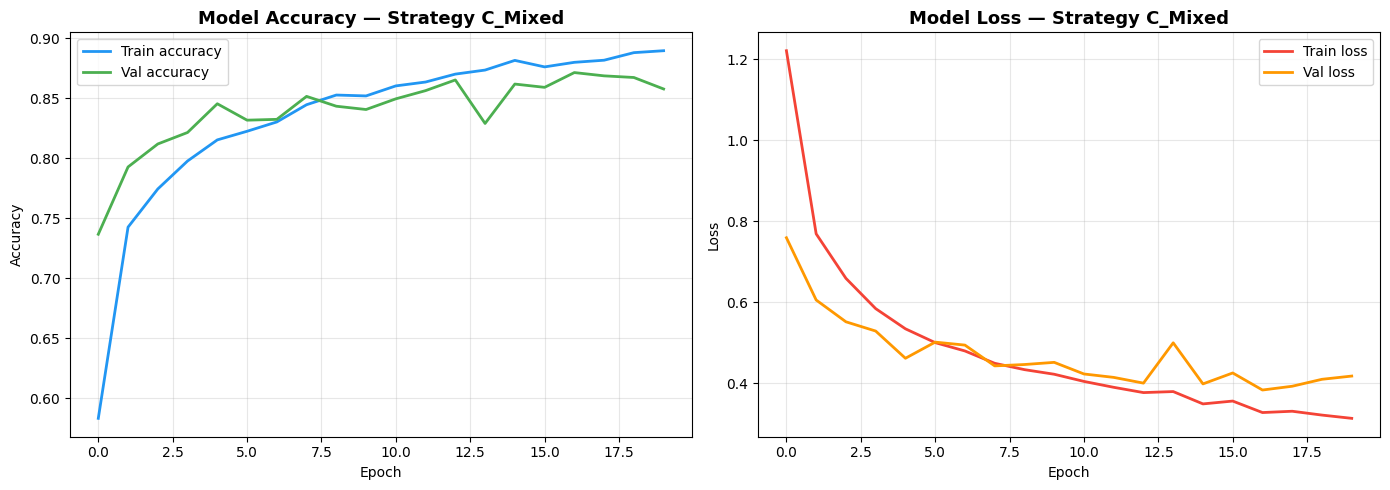


📊 Strategy C_Mixed Final Results:
   Best Train Accuracy : 88.96%
   Best Val Accuracy   : 87.14%
   Final Train Loss    : 0.3126
   Final Val Loss      : 0.4172


In [7]:
#Cell 6 — Plot Training Curves
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy
axes[0].plot(history.history['accuracy'],
             label='Train accuracy', color='#2196F3', linewidth=2)
axes[0].plot(history.history['val_accuracy'],
             label='Val accuracy', color='#4CAF50', linewidth=2)
axes[0].set_title(f'Model Accuracy — Strategy {STRATEGY}',
                  fontsize=13, fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Loss
axes[1].plot(history.history['loss'],
             label='Train loss', color='#F44336', linewidth=2)
axes[1].plot(history.history['val_loss'],
             label='Val loss', color='#FF9800', linewidth=2)
axes[1].set_title(f'Model Loss — Strategy {STRATEGY}',
                  fontsize=13, fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
os.makedirs("../outputs", exist_ok=True)
plt.savefig(f"../outputs/training_curves_{STRATEGY}.png",
            dpi=150, bbox_inches='tight')
plt.show()

print(f"\n📊 Strategy {STRATEGY} Final Results:")
print(f"   Best Train Accuracy : {max(history.history['accuracy']):.2%}")
print(f"   Best Val Accuracy   : {max(history.history['val_accuracy']):.2%}")
print(f"   Final Train Loss    : {history.history['loss'][-1]:.4f}")
print(f"   Final Val Loss      : {history.history['val_loss'][-1]:.4f}")

In [9]:
#Cell 7 — Evaluate on Test Set
print(f"🔄 Evaluating Strategy {STRATEGY} on test set...\n")

test_loss, test_accuracy = model.evaluate(test_generator, verbose=1)

print(f"\n{'='*45}")
print(f"📊 Strategy {STRATEGY} — Test Results")
print(f"{'='*45}")
print(f"✅ Test Accuracy : {test_accuracy:.2%}")
print(f"📉 Test Loss     : {test_loss:.4f}")
print(f"{'='*45}")

# Direct comparison with Strategy A
print(f"\n📈 Strategy Comparison So Far:")
print(f"  Strategy A (Color only)     : 89.06%")
print(f"  Strategy B (Color only)     : 86.85%")
print(f"  Strategy C (Mixed Dataset) : {test_accuracy:.2%}  ← new result")
print(f"\n  Difference_Strategy_A: {(test_accuracy - 0.8906)*100:+.2f}%")
print(f"\n  Difference_strategy_B: {(test_accuracy - 0.8685)*100:+.2f}%")

🔄 Evaluating Strategy C_Mixed on test set...

46/46 ━━━━━━━━━━━━━━━━━━━━ 38s 835ms/step - accuracy: 0.8748 - loss: 0.3631

📊 Strategy C_Mixed — Test Results
✅ Test Accuracy : 87.48%
📉 Test Loss     : 0.3631

📈 Strategy Comparison So Far:
  Strategy A (Color only)     : 89.06%
  Strategy B (Color only)     : 86.85%
  Strategy C (Mixed Dataset) : 87.48%  ← new result

  Difference_Strategy_A: -1.58%

  Difference_strategy_B: +0.63%


In [10]:
#Cell 8 — Save Model & Results
# Save final model
final_path = os.path.join(MODEL_PATH, f'model_{STRATEGY}_final.h5')
model.save(final_path)

# Save results to a text file for comparison later
results_path = r"D:\Development\8th Sem Project\TomatoClassification\outputs\results_summary.txt"
os.makedirs(os.path.dirname(results_path), exist_ok=True)

with open(results_path, 'a') as f:
    f.write(f"\nStrategy {STRATEGY}\n")
    f.write(f"  Test Accuracy : {test_accuracy:.4f}\n")
    f.write(f"  Test Loss     : {test_loss:.4f}\n")
    f.write(f"  Best Val Acc  : {max(history.history['val_accuracy']):.4f}\n")

print(f"✅ Model saved : {final_path}")
print(f"📝 Results logged to : {results_path}")
print(f"\n📁 Models folder now contains:")
for f in os.listdir(MODEL_PATH):
    size = os.path.getsize(os.path.join(MODEL_PATH, f)) / (1024*1024)
    print(f"   {f} — {size:.1f} MB")

✅ Model saved : D:\Development\8th Sem Project\TomatoClassification\models\model_C_Mixed_final.h5
📝 Results logged to : D:\Development\8th Sem Project\TomatoClassification\outputs\results_summary.txt

📁 Models folder now contains:
   best_model.h5 — 11.0 MB
   best_model_B_segmented.h5 — 11.0 MB
   best_model_C_Mixed.h5 — 11.0 MB
   model_B_segmented_final.h5 — 11.0 MB
   model_C_Mixed_final.h5 — 11.0 MB
   tomato_classifier_final.h5 — 11.0 MB
